In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import PIL
import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras


In [3]:
# Check if GPU is available
print("GPU Available: ", tf.config.list_physical_devices('GPU'))
print("Built with CUDA: ", tf.test.is_built_with_cuda())

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

GPU Available:  []
Built with CUDA:  False
TensorFlow version: 2.20.0


In [4]:
dataset_train=tf.keras.preprocessing.image_dataset_from_directory(
    "training",
    shuffle=True,
    image_size=(256,256),
    batch_size=32
)


Found 5712 files belonging to 4 classes.


In [5]:
class_names=dataset_train.class_names
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [6]:
dataset_test=tf.keras.preprocessing.image_dataset_from_directory(
    "testing",
    shuffle=True,
    image_size=(256,256),
    batch_size=32
)

Found 1311 files belonging to 4 classes.


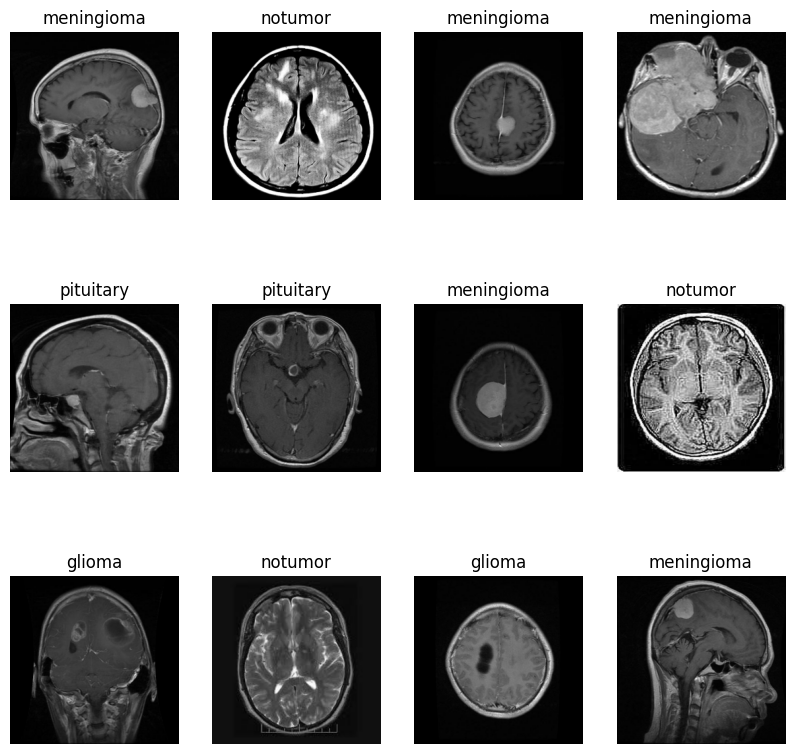

In [7]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset_train.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

In [8]:
dataset_train = dataset_train.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
dataset_test = dataset_test.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [9]:
resize_and_rescale = tf.keras.Sequential([
  tf.keras.layers.Resizing(256,256),
  tf.keras.layers.Rescaling(1./255),
])

In [10]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
])

In [11]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=50

In [12]:
dataset_train = dataset_train.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [13]:
from keras import models
from keras import layers

In [14]:
# Create base model using Keras applications
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,  # Remove the top classification layer
    weights='imagenet',
    pooling='avg'  # Add global average pooling
)
base_model.trainable = False

# Now use this in your Sequential model
n_classes=4
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    resize_and_rescale,
    base_model,
    tf.keras.layers.Dense(n_classes, activation='softmax'),
])

C:\Users\puska\AppData\Local\Temp\ipykernel_4264\3647519630.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [15]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Just the string name
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    dataset_train,
    batch_size=BATCH_SIZE,
    verbose=1,
    epochs=5,
)

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 185s 876ms/step - accuracy: 0.7756 - loss: 0.5993
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 139s 778ms/step - accuracy: 0.8654 - loss: 0.3758
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 136s 756ms/step - accuracy: 0.8782 - loss: 0.3387
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 140s 782ms/step - accuracy: 0.8946 - loss: 0.3032
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 135s 754ms/step - accuracy: 0.8990 - loss: 0.2892


In [18]:
scores = model.evaluate(dataset_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 28s 564ms/step - accuracy: 0.8391 - loss: 0.4169


first image to predict
actual label: pituitary
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
predicted label: pituitary


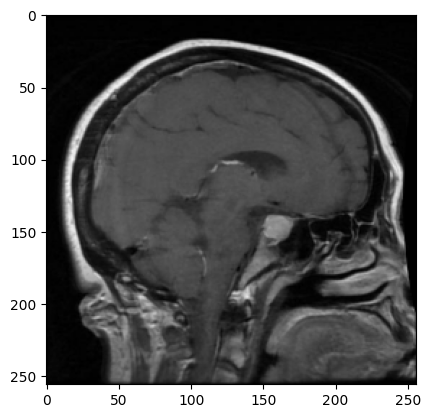

In [19]:
for images_batch, labels_batch in dataset_test.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [20]:
acc = history.history['accuracy']
loss = history.history['loss']

In [21]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


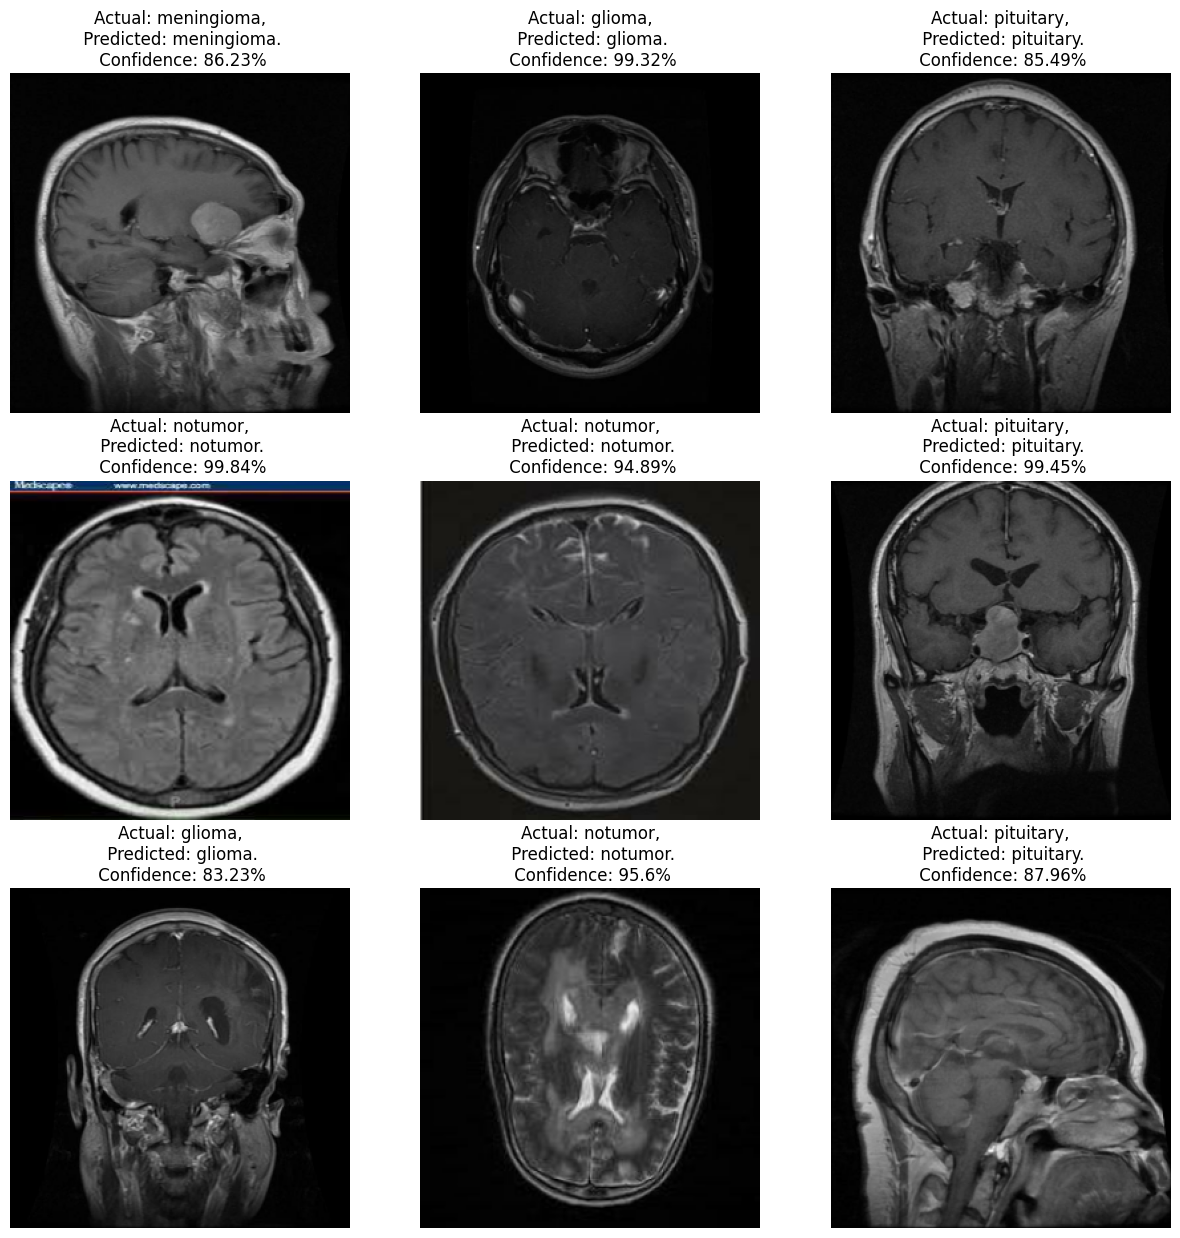

In [22]:
plt.figure(figsize=(15, 15))
for images, labels in dataset_test.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [23]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.cm as cm

def get_heatmap_for_mobilenet(model, img_array, pred_index=None):
    """
    Grad-CAM specifically for the nested MobileNetV2 architecture.
    """
    # 1. Unpack the layers from your 'sequential_2' model
    # layer[0]: sequential (preprocessing)
    # layer[1]: mobilenetv2_1.00_224 (base feature extractor)
    # layer[2]: dense (classifier)
    preprocess_layer = model.layers[0]
    base_model = model.layers[1]
    classifier_layer = model.layers[2]
    
    # 2. Access the internal convolutional layer of MobileNetV2
    # 'out_relu' is usually the last activation layer in MobileNetV2 (7x7x1280)
    # If this fails, try 'Conv_1'
    last_conv_layer_name = 'out_relu' 
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # 3. Create a sub-model that returns BOTH the conv features AND the pooled output
    # We use the base_model's own inputs and outputs to bridge the gap
    feature_extractor = tf.keras.models.Model(
        inputs=base_model.inputs, 
        outputs=[last_conv_layer.output, base_model.output]
    )

    # 4. GradientTape to track the flow
    with tf.GradientTape() as tape:
        # A. Pass input through preprocessing
        x = preprocess_layer(img_array)
        
        # B. Pass through the base model extractor
        # conv_outputs: the 7x7 spatial features (4D)
        # pooled_output: the 1280 vector (2D)
        conv_outputs, pooled_output = feature_extractor(x)
        
        # C. Pass the pooled vector through the final dense layer
        preds = classifier_layer(pooled_output)
        
        # D. Get the target class score
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 5. Compute Gradients of the class score wrt the feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # 6. Pool the gradients (Global Average Pooling)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Weight the feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. Post-process (ReLU + Normalize)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

def overlay_heatmap(original_image, heatmap, alpha=0.5):
    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)
    
    # Colorize (Jet colormap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    # Resize to match original image
    jet_heatmap = cv2.resize(jet_heatmap, (original_image.shape[1], original_image.shape[0]))
    
    # Convert to standard image format and overlay
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = np.array(jet_heatmap)
    
    superimposed_img = jet_heatmap * alpha + original_image
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    
    return superimposed_img

C:\Users\puska\AppData\Local\Temp\ipykernel_4264\1608301470.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


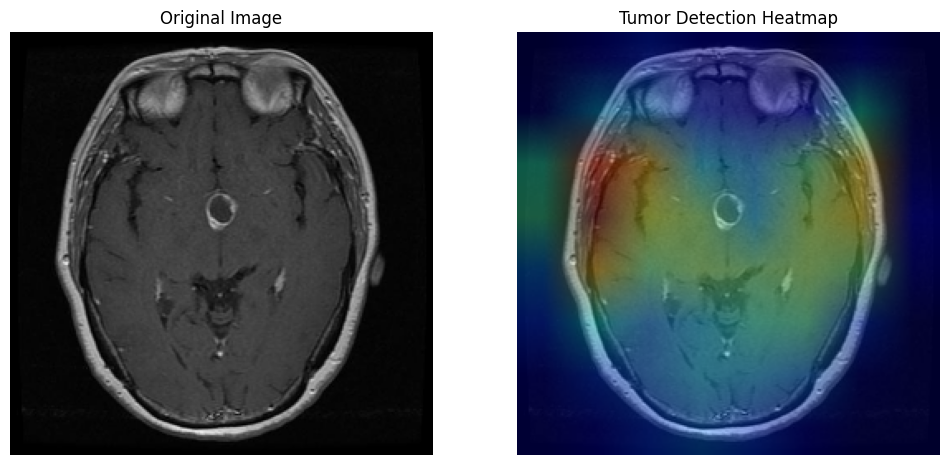

In [24]:
# 1. Prepare the image (Resize to 256x256 as per your model input)
img_path = "testing/pituitary/Te-pi_0022.jpg"  # <--- REPLACE THIS
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(256, 256))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0) # Shape: (1, 256, 256, 3)

# 2. Generate Heatmap
# Note: We don't need to pass a layer name anymore, it's hardcoded for MobileNetV2
heatmap = get_heatmap_for_mobilenet(model, img_array)

# 3. Display
import matplotlib.pyplot as plt

original_img = tf.keras.preprocessing.image.img_to_array(img)
final_img = overlay_heatmap(original_img, heatmap)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Tumor Detection Heatmap")
plt.imshow(final_img)
plt.axis("off")
plt.show()

In [25]:
# The modern, recommended way
model.save('brain_tumor_model.keras')

print("Model saved successfully in the new Keras format!")

Model saved successfully in the new Keras format!
